# Seminar 2.  Sequential Bayesian Learning

In [3]:
import numpy as np
from scipy.stats import multivariate_normal as mvn
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt

%matplotlib inline

Let $ D = \{(x_i, y_i)\}_{i=1}^N $, where $ x_i \in \mathbb{R}^d $, $ y_i \in \mathbb{R} $. We assume the following generative model:

1. Unknown parameters $ \theta $ are sampled from a prior:
   $$
   \theta \sim \mathcal{N}(0, \sigma_\theta^2 I)
   $$

2. The data $ D $ are generated independently and identically (i.i.d.) from the conditional distribution:
   $$
   P(x, y \mid \theta) = P(x) P(y \mid x, \theta)
   $$

3. The likelihood model is Gaussian:
   $$
   P(y \mid x, \theta) \sim \mathcal{N}(y|\theta^\top x, \sigma^2)
   $$
   where $ \sigma^2 $ is known noise variance.

**Goal**: Find a function that takes an input vector $ \vec{x} $ and predicts $ y $, despite the true parameters $ \theta $ being unknown.

---

### Solution

We aim to compute the posterior distribution over the parameters $ \theta $ given the data:
$$
P(\theta \mid D) = \frac{P(D \mid \theta) P(\theta)}{P(D)}
$$

Since the data points are independent:
$$
P(D \mid \theta) = \prod_{i=1}^N P(x_i, y_i \mid \theta) = \prod_{i=1}^N P(y_i \mid x_i, \theta) P(x_i)
$$
Note: $ P(x_i) $ is assumed to be uniformely distributed on bounded support so we treat it as constant when computing the posterior.

Thus,
$$
P(\theta \mid D) \propto P(\theta) \prod_{i=1}^N P(y_i \mid x_i, \theta)
$$

Substituting the Gaussian forms:

- Prior:  
  $$
  P(\theta) \propto \exp\left( -\frac{\|\theta\|^2}{2\sigma_\theta^2} \right)
  $$

- Likelihood:  
  $$
  P(y_i \mid x_i, \theta) \propto \exp\left( -\frac{(y_i - \theta^\top x_i)^2}{2\sigma^2} \right)
  $$

Therefore, the posterior becomes:
$$
P(\theta \mid D) \propto \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^N (y_i - \theta^\top x_i)^2 - \frac{\|\theta\|^2}{2\sigma_\theta^2} \right)
$$

This corresponds to a **Gaussian posterior**, since the exponent is quadratic in $ \theta $.

Let us define:
- Design matrix: $ X \in \mathbb{R}^{N \times d} $, with rows $ x_i^\top $
- Target vector: $ \vec{Y} \in \mathbb{R}^N $, with entries $ y_i $

Then:
$$
\sum_{i=1}^N (y_i - \theta^\top x_i)^2 = \| \vec{Y} - X\theta \|^2
$$

So,
$$
P(\theta \mid D) \propto \exp\left( -\frac{1}{2\sigma^2} (\vec{Y} - X\theta)^\top (\vec{Y} - X\theta) - \frac{1}{2\sigma_\theta^2} \theta^\top \theta \right)
$$

Completing the square, this is equivalent to:
$$
P(\theta \mid D) = \mathcal{N}(\theta \mid \mu, \Lambda^{-1})
$$
where:
$$
\Lambda = \frac{1}{\sigma^2} X^\top X + \frac{1}{\sigma_\theta^2} I
$$
$$
\mu = \frac{1}{\sigma^2} \Lambda^{-1} X^\top \vec{Y}
$$

---

### Maximum A Posteriori (MAP) Estimate

$$
\theta_{\text{MAP}} = \arg\max_\theta P(\theta \mid D) = \mu = \left( X^\top X + \frac{\sigma^2}{\sigma_\theta^2} I \right)^{-1} X^\top \vec{Y}
$$

Compare to Maximum Likelihood Estimate (MLE):
$$
\theta_{\text{MLE}} = (X^\top X)^{-1} X^\top \vec{Y}
$$

Thus, Bayesian linear regression with a Gaussian prior leads to **ridge regression (L₂ regularization)**.

---

### Predictive Distribution

Now suppose we observe a new input $ x $ and want to predict the output $ y $. We compute the **posterior predictive distribution**:
$$
P(y \mid x, D) = \int P(y \mid x, \theta) P(\theta \mid D) \, d\theta
$$

Since both $ P(y \mid x, \theta) $ and $ P(\theta \mid D) $ are Gaussian, their product integrates to another Gaussian.

We compute:
$$
P(y \mid x, D) = \int \mathcal{N}(y \mid \theta^\top x, \sigma^2) \cdot \mathcal{N}(\theta \mid \mu, \Lambda^{-1}) \, d\theta
$$

The result is:
$$
P(y \mid x, D) = \mathcal{N}\left( y \mid \mu^\top x,\ \sigma^2 + x^\top \Lambda^{-1} x \right)
$$

That is:
$$
y \mid x, D \sim \mathcal{N}\left( \mu^\top x,\ \sigma^2 + x^\top \Lambda^{-1} x \right)
$$

This gives not only a prediction but also a measure of uncertainty — a key advantage of the Bayesian approach.



### Sequential Bayesian Learning
$$
P(\theta | D_1, D_2) = \frac{P(D_2 | \theta) P(\theta | D_1)}{P(D_2 | D_1)}
$$
$$
P(D_2 | D_1) = \int P(D_2)P(\theta|D_1)d\theta
$$
We have the same task as before with new "prior" on $\theta$

### Task 1

Here, we define our model:

In [4]:
class BLR:
    def __init__(self, A, beta, x_dim=2):
        self.w_Pr = {"mu": np.zeros(x_dim), "cov": np.linalg.inv(A), "inv_cov": A}
        self.beta = beta

    def update_w(self, X, y, verbose=False):
        inv_cov = self.beta * X.T @ X + self.w_Pr["inv_cov"]
        cov = np.linalg.inv(inv_cov)
        mu = cov @ (
            self.beta * X.T @ y[:, None]
            + self.w_Pr["inv_cov"] @ self.w_Pr["mu"][:, None]
        )

        self.w_Pr = {"mu": mu.flatten(), "cov": cov, "inv_cov": inv_cov}
        return {"mu": mu.flatten(), "cov": cov, "inv_cov": inv_cov} if verbose else 0.0

    def plot_w_space(self, ax, b=15.0):
        xx, yy = np.mgrid[-b:b:0.01, -b:b:0.01]
        grid = np.c_[xx.ravel(), yy.ravel()]
        probs = mvn.logpdf(grid, mean=self.w_Pr["mu"], cov=self.w_Pr["cov"])
        contour = ax.contourf(xx, yy, probs.reshape(xx.shape))

    def plot_data_space(self, x, y, ax):
        a, b = (-1.1, 1.1)
        for i in range(50):
            w = np.random.multivariate_normal(self.w_Pr["mu"], self.w_Pr["cov"])
            ax.plot(
                np.array([a, b]),
                np.array([w[0] + w[1] * a, w[0] + w[1] * b]),
                "r-",
                alpha=0.15,
            )

        ax.scatter(
            x[:, :, 1].flatten(),
            y.flatten(),
            edgecolor="white",
            alpha=0.75,
            color="blue",
        )
        ax.scatter(
            x[-1, :, 1].flatten(),
            y[-1].flatten(),
            edgecolor="white",
            alpha=1.0,
            color="green",
        )

    def plot_poly_data_space(self, x, y, ax, k=2):
        k_points = np.linspace(-1.1, 1.1, num=k + 1)
        for i in range(50):
            w = np.random.multivariate_normal(self.w_Pr["mu"], self.w_Pr["cov"])
            poly_values = np.zeros_like(k_points)
            poly_values = polyval(k_points, w)
            ax.plot(k_points, poly_values, "r-", alpha=0.15)

        ax.scatter(
            x[:, :, 1].flatten(),
            y.flatten(),
            edgecolor="white",
            alpha=0.75,
            color="blue",
        )
        ax.scatter(
            x[-1, :, 1].flatten(),
            y[-1].flatten(),
            edgecolor="white",
            alpha=1.0,
            color="green",
        )

In [5]:
reg = BLR(np.diag([0.1, 0.1]), 1.0)

In [6]:
# make matrice X
x1 = np.linspace(-1, 1, 10)
np.random.shuffle(x1)
x1 = x1.reshape(5, 2)
x0 = np.ones_like(x1)
X = np.stack([x0, x1], axis=-1)

# make targets y
y = 1.5 + 12.0 * x1
y += np.random.randn(*y.shape) * 3.5

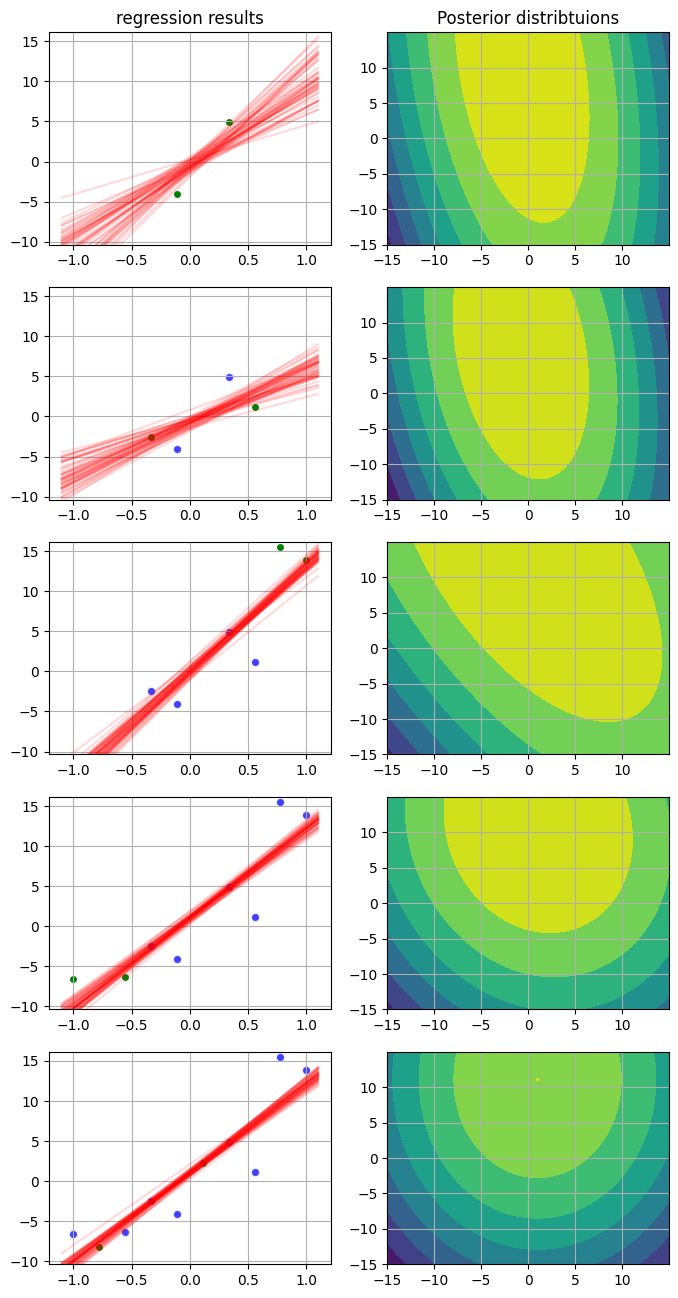

In [7]:
chunks = 5  # divide dataset to 5 parts (M=5)

# plotting utils
fig, ax = plt.subplots(chunks, 2, figsize=(8, 16))
ymin, ymax = y[:, 1].min(), y[:, 1].max()
yrange = ymax - ymin
ymin, ymax = ymin - 0.1 * yrange, ymax + 0.1 * yrange

for i in range(chunks):
    reg.update_w(X[i], y[i])
    reg.plot_data_space(X[: i + 1], y[: i + 1], ax[i, 0])
    ax[i, 0].set_ylim(ymin, ymax)
    reg.plot_w_space(ax[i, 1])
    ax[i, 0].grid(), ax[i, 1].grid()
    ax[0, 0].set_title("regression results")
    ax[0, 1].set_title("Posterior distribtuions")

### task: compute and plot mean and 0.95 confidence interval for predictive distribution
you can use `fill_between` function from matplotlib (see https://matplotlib.org/stable/gallery/lines_bars_and_markers/fill_between_demo.html#sphx-glr-gallery-lines-bars-and-markers-fill-between-demo-py)

In [9]:
# your code is here

### 2. Logistic and probit regression. Bayesian logistic regression. Laplace approximation

#### 2.1 Classification problem
The natural starting point for discussing approaches to classification is the joint probability $p(y, \mathbf{x})$, where $y$ denotes the class label. Using Bayes' theorem this joint probability can be decomposed either as $p(y) p(\mathbf{x}|y)$ or as $p(\mathbf{x}) p(y|\mathbf{x})$. This gives rise to two different approaches to classification problems. The first, which we call the generative approach, models the class-conditional distributions $p(\mathbf{x}|y)$ for $y=\mathcal{C}_1, \ldots, \mathcal{C}_C$ and also the prior probabilities of each class, and then computes the posterior probability for each class using

$$
p(y|\mathbf{x})=\frac{p(y) p(\mathbf{x}|y)}{\sum_{c=1}^C p\left(\mathcal{C}_c\right) p\left(\mathbf{x}|\mathcal{C}_c\right)}
$$


The alternative approach, which we call the discriminative approach, focusses on modelling $p(y|\mathbf{x})$ directly.  
To turn both the generative and discriminative approaches into practical methods we will need to create models for either $p(\mathbf{x}|y)$, or $p(y|\mathbf{x})$ respectively.
#### 2.2 Logistic and probit regression
##### 2.2.1 Modeling
For the binary discriminative case one simple idea is to turn the output of a regression model into a class probability using a response function (the inverse of a link function), which "squashes" its argument, which can lie in the domain $(-\infty, \infty)$, into the range $[0,1]$, guaranteeing a valid probabilistic interpretation.

One example is the **linear logistic regression** model

$$
p\left(y=1|\mathbf{x}, \boldsymbol{\theta}\right)=\lambda\left(\mathbf{x}^{\top} \boldsymbol{\theta}\right), \quad \text { where } \lambda(z)=\frac{1}{1+\exp (-z)}, \quad \mathbf{x},\boldsymbol{\theta}\in \mathbb{R}^D,\, y\in\{0,1\}
$$

which combines the linear model with the logistic response function. Another common choice of response function is the cumulative density function of a standard normal distribution $\Phi(z)=\int_{-\infty}^z \mathcal{N}(x|0,1) d x$. This approach is known as **probit regression**.

We have datasets $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n,\, \text{where } \mathbf{x}_i, y_i\sim p(\mathbf{x}, y)$ $-$ iid samples.
Assuming that $\mathbf{x}$ is a uniformly distributed on finite support random value, we can write down probability of observed data given parameters $\boldsymbol{\theta}$, i.e *likelihood*:

$$
\mathcal{L}(\boldsymbol{\theta})=p(\mathcal{D}|\boldsymbol{\theta}) = p((\mathbf{x}_1, y_1),\dots,(\mathbf{x}_n, y_n)|\boldsymbol{\theta}) \underset{\text{iid}}{=} \prod_{i=1}^n p(\mathbf{x}_i,y_i|\boldsymbol{\theta}) = \prod_{i=1}^n p(y_i|\mathbf{x}_i, \boldsymbol{\theta})p(\mathbf{x}_i) = C\prod_{i=1}^n p(y_i|\mathbf{x}_i, \boldsymbol{\theta}), \quad \text{where } C = c^n,\, c - \text{constant dencity of }\mathbf{x}_i
$$

In linear logistic regression approach, we model class probabilities in following way:  
$p(y=1|\mathbf{x}_i, \boldsymbol{\theta}) = \lambda\left(\mathbf{x}_i^{\top} \boldsymbol{\theta}\right)\equiv p_i$,  
$p(y=0|\mathbf{x}_i,\boldsymbol{\theta}) = 1-\lambda\left(\mathbf{x}_i^{\top} \boldsymbol{\theta}\right)\equiv 1 - p_i$

With this model and notation, we can rewrite likelihood:
$$
\mathcal{L}(\boldsymbol{\theta}) = C\prod_{i=1}^n p^{y_i}_i(1-p_i)^{1-y_i}
$$ 

##### 2.2.2 MLE arroach
We can assume that papameters $\boldsymbol{\theta}$ are deterministic and unknown. We want to find most suited values $\boldsymbol{\theta}^*$. With assumptions above, a reasonable value would be Maximum Likelihood Estimate (MLE):

$$
\boldsymbol{\theta}^* = \underset{\boldsymbol{\theta}}{\text{argmax }}\mathcal{L}(\boldsymbol{\theta})
$$
which yield estimate with highest observed data probability.

$$
\underset{\boldsymbol{\theta}}{\text{argmax }}\mathcal{L}(\boldsymbol{\theta}) = \underset{\boldsymbol{\theta}}{\text{argmax }}\log p(\mathcal{D}|\boldsymbol{\theta}) = \underset{\boldsymbol{\theta}}{\text{argmax }} \sum^n_{i=1} y_i\log p_i + (1-y_i)\log (1-p_i)
$$

$$
\frac{\partial}{\partial \theta_j} \log p(\mathcal{D}|\boldsymbol{\theta}) = \sum_{i=1}^n\left[ \frac{y_i}{p_i}\frac{\partial}{\partial \theta_j}p_i - \frac{1-y_i}{1-p_i}\frac{\partial}{\partial \theta_j}p_i\right]
$$

$$
\frac{\partial}{\partial \theta_j}p_i = x_{ij}p_i(1-p_i)
$$

$$
\frac{\partial}{\partial \theta_j} \log p(\mathcal{D}|\boldsymbol{\theta}) =\sum_{i=1}^n x_{ij}\left[ \frac{y_i}{p_i}\frac{\partial}{\partial \theta_j}p_i - \frac{1-y_i}{1-p_i}\frac{\partial}{\partial \theta_j}p_i\right] = \sum_{i=1}^n x_{ij}\left[y_i-p_i\right]
$$

$$
\nabla_{\boldsymbol{\theta}}\log p(\mathcal{D}|\boldsymbol{\theta}) = \sum_{i=1}^n \mathbf{x}_{i}\left[y_i-p_i\right]
$$

$$
H(\boldsymbol{\theta}) = \frac{\partial}{\partial \theta_j \partial \theta_k} \log p(\mathcal{D}|\boldsymbol{\theta}) = -\sum_{i=1}^n x_{ij}x_{ik}p_i(1-p_i) = -X^TRX,\quad R=\text{diag}(p_i(1-p_i))
$$

We see, that Hessian is negative defines, thus optimization objective is concave.  
Convex optimization MLE:

$$
\boldsymbol{\theta}^{\text{new}} = \boldsymbol{\theta}^{\text{old}} + H^{-1}(\boldsymbol{\theta}^{\text{old}})\nabla_{\boldsymbol{\theta}^{\text{old}}}\log p(\mathcal{D}|\boldsymbol{\theta}^{\text{old}})
$$


#### 2.3 Bayesian linear logistic regression. Laplace approximation

Following bayesian linear regression, we want to incert some domaine knowledge and put prior on model parameters:
$$
\boldsymbol{\theta} \sim p(\boldsymbol{\theta})
$$

In order to obtain predictive model, one should marginalize $\boldsymbol{\theta}$ using posterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$:
$$
p(y|\mathbf{x}, \mathcal{D}) = \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})p(\boldsymbol{\theta}|\mathcal{D})d\boldsymbol{\theta}
$$

$$
p(\boldsymbol{\theta}|\mathcal{D}) = \frac{p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})}{p(\mathcal{D})}, \quad \text{where } p(\mathcal{D})=\int_{\boldsymbol{\theta}}p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})d\boldsymbol{\theta}
$$

It is hard to compute porterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$, due to difficulty of evidence computatation $p(\mathcal{D})$.

##### 2.3.1 Laplace approximation

We could approximate $p(\boldsymbol{\theta}|\mathcal{D})$ with some distribution $q(\boldsymbol{\theta})$. Then
$$
p(y|\mathbf{x}, \mathcal{D})\approx \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})q(\boldsymbol{\theta})d\boldsymbol{\theta}
$$

Let
$$
p(z) = \frac{1}{Z}f(z), \quad Z=\int_{z}f(z)dz
$$
In our task, $z=\boldsymbol{\theta}, f(\boldsymbol{\theta}) = p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})$

We want to find $q(z)\approx p(z)$
1. $\left.\frac{\partial f(z)}{\partial z}\right|_{z=z_0}=0$
2. $\log f(z)\approx \log f(z_0) - \frac{1}{2}(z-z_0)^TA(z-z_0)$, $\quad A=-\left.\nabla^2_{z}\log f(z)\right|_{z=z_0}$

So
$$
f(z)\approx f(z_0)\exp\left(-\frac{1}{2}(z-z_0)^TA(z-z_0)\right)\Rightarrow Z \approx \int_{z}f(z_0)\exp\left(-\frac{1}{2}(z-z_0)^TA(z-z_0)\right)dz
$$

$$
q(z) \sim \mathcal{N}(z|z_0, A^{-1})
$$

Drawbacks:
1. Local
2. Unimodal

##### 2.3.2 Bayesian linear logistic regression with Laplace approximation

$$
p(\boldsymbol{\theta}) \sim \mathcal{N}(\boldsymbol{\theta}|\boldsymbol{\mu}, S_0)
$$

$$
p(\boldsymbol{\theta}|\mathcal{D}) \propto p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})
$$
$$
\log p(\boldsymbol{\theta}|\mathcal{D}) \propto \sum^n_{i=1}\left[ y_i\log p_i + (1-y_i)\log (1-p_i)\right] - \frac{1}{2}(\boldsymbol{\theta} - \boldsymbol{\mu})^TS_0^{-1}(\boldsymbol{\theta} - \boldsymbol{\mu}), \quad \text{where }p_{i} = \lambda(\boldsymbol{\theta}^T\mathbf{x}_i)
$$
Laplace approximation:
$$
p(\boldsymbol{\theta}|\mathcal{D}) \approx q(\boldsymbol{\theta}) \sim \mathcal{N}(\boldsymbol{\theta}|\boldsymbol{\theta}_{\text{MAP}}, S_n)
$$

$$
S_n = -\nabla^2_{\boldsymbol{\theta}}\log p(\boldsymbol{\theta}|\mathcal{D}) = \sum_{i=1}^n x_ix_i^Tp_i(1-p_i) + S_0^{-1} = X^TRX + S_0^{-1},\quad R=\text{diag}(p_i(1-p_i))
$$

Predictive distribution:
$$
p(y=1|\mathbf{x}, \mathcal{D}) = \int_{\boldsymbol{\theta}}p(y=1|\mathbf{x}, \boldsymbol{\theta})p(\boldsymbol{\theta}|\mathcal{D})d\boldsymbol{\theta}\approx \int_{\boldsymbol{\theta}}\underbrace{p(y|\mathbf{x}, \boldsymbol{\theta})}_{\lambda(\boldsymbol{\theta}^T\mathbf{x})}q(\boldsymbol{\theta})d\boldsymbol{\theta}
$$

This still doesn’t have a closed form, but there’s a well-known analytical approximation:

$$
p(y=1|x, \mathcal{D}) \approx \lambda\left( \frac{\mu_a}{\sqrt{1 + \pi \sigma_a^2 / 8}} \right),\quad \text{where}
\begin{cases}
\mu_a = \boldsymbol{\theta}_{\text{MAP}}^T x_* \\
\sigma_a^2 = x^T S_n^{-1} x
\end{cases}
$$



#### Task 2: compute uncertainty estimate in 2d binary classification task using Laplace approximation

In [13]:
np.random.seed(42)
N = 50  # number of points per class

# Class 0
X0 = np.random.randn(N, 2) + [-1, -1]
y0 = np.zeros(N)

# Class 1
X1 = np.random.randn(N, 2) + [1, 1]
y1 = np.ones(N)

# Combine
X = np.vstack([X0, X1])  # shape (100, 2)
y = np.hstack([y0, y1])  # shape (100,)

# Add bias term (intercept): x becomes [x1, x2, 1]
X_with_bias = np.c_[X, np.ones(2 * N)]

In [ ]:
# your code is here